# Two-Stage NSBH Impact: f_j^{BNS} Comparison (Log-Normal Geometry)

Compare Stage 2 posteriors for BNS and NSBH angles across three f_j^{BNS} values:
- f_j^{BNS} = 0.1
- f_j^{BNS} = 0.5
- f_j^{BNS} = 1.0

This notebook uses the log-normal geometric efficiency beaming fraction.

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, '../..')

plt.style.use('../../configurations/style.mplstyle')
datafiles = Path('../../datafiles')

from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import create_geometric_efficiency_lognormal_interpolator
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS
from scipy.stats import gaussian_kde
import src.init

print('Imports complete.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports complete.


In [6]:
# Run configurations
from mcmc_runner import run_populations

possible_alpha = ["A0.5", "A1.0", "A3.0", "A5.0"]
FJ_BNS_VALUES  = [0.1, 0.5, 1.0]

SIGMA_THETA_C = 0.5  # log10-space width for lognormal
geom_eff_interp = create_geometric_efficiency_lognormal_interpolator(
    sigma_theta_c=SIGMA_THETA_C,
    n_points=200,
    minimum_theta_c=1.0,
    maximum_theta_c=25.0,
)

# Run the MC chains for all alphas and fj combinations.
run_populations(
    alphas=possible_alpha,
    fj_bns_values=FJ_BNS_VALUES,
    geom_eff_func=geom_eff_interp, 
    datafiles=datafiles,
    n_params_1=5, n_walkers_1=24, n_steps_1=10_000,
    n_params_2=2, n_walkers_2=24, n_steps_2=10_000,
    burn_frac=0.33, thin=10
)


Running MCMC pipeline for alpha = A0.5
Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332

--- Running for FJ_BNS = 0.1 ---
Loading existing directory  : Output_files/lognormal_stage1_bns_only_alpha_A0.5_fj0.1
Continuing from iteration 5000


100%|██████████| 5000/5000 [05:43<00:00, 14.55it/s]


Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A0.5_fj0.1
Continuing from iteration 5000


100%|██████████| 5000/5000 [08:35<00:00,  9.70it/s]



--- Running for FJ_BNS = 0.5 ---
Loading existing directory  : Output_files/lognormal_stage1_bns_only_alpha_A0.5_fj0.5
Continuing from iteration 5000


...

100%|██████████| 5000/5000 [08:17<00:00, 10.05it/s]



--- Running for FJ_BNS = 1.0 ---
Loading existing directory  : Output_files/lognormal_stage1_bns_only_alpha_A5.0_fj1.0
Continuing from iteration 5000


100%|██████████| 5000/5000 [05:31<00:00, 15.10it/s]


Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A5.0_fj1.0
Continuing from iteration 5000


100%|██████████| 5000/5000 [08:12<00:00, 10.16it/s]


Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A0.5_fj0.1
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A0.5_fj0.5
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A0.5_fj1.0


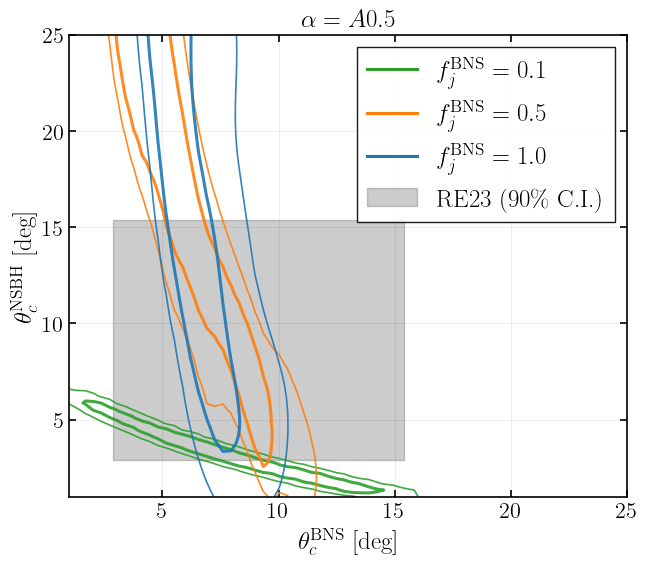

Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A1.0_fj0.1
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A1.0_fj0.5
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A1.0_fj1.0


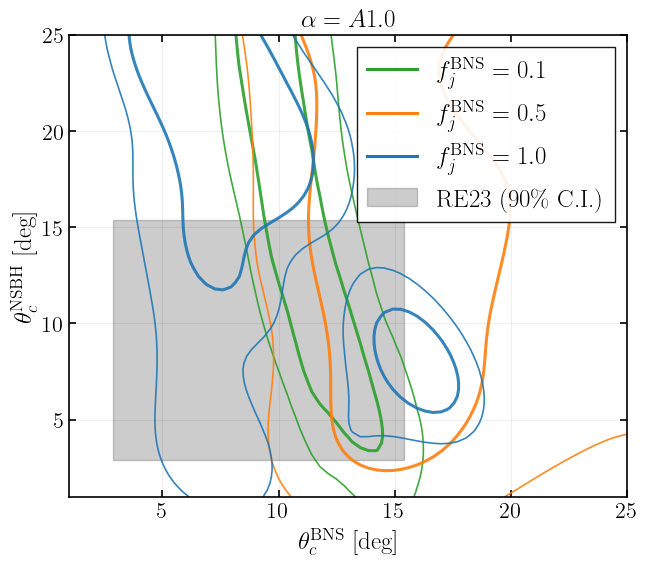

Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A3.0_fj0.1
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A3.0_fj0.5
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A3.0_fj1.0


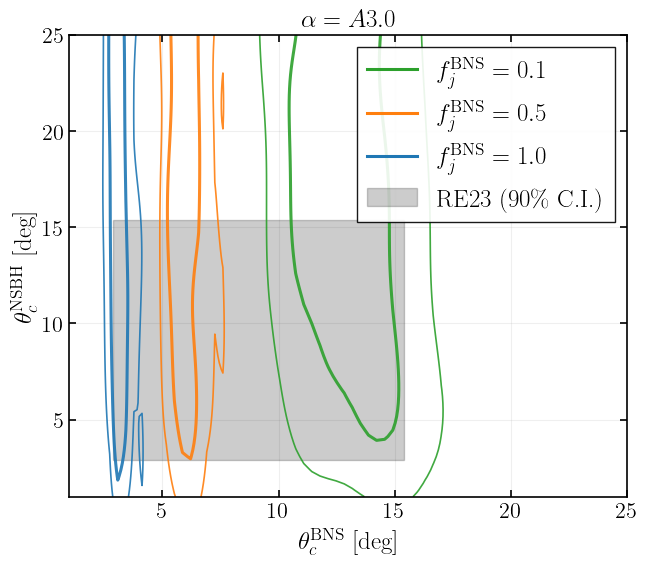

Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A5.0_fj0.1
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A5.0_fj0.5
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A5.0_fj1.0


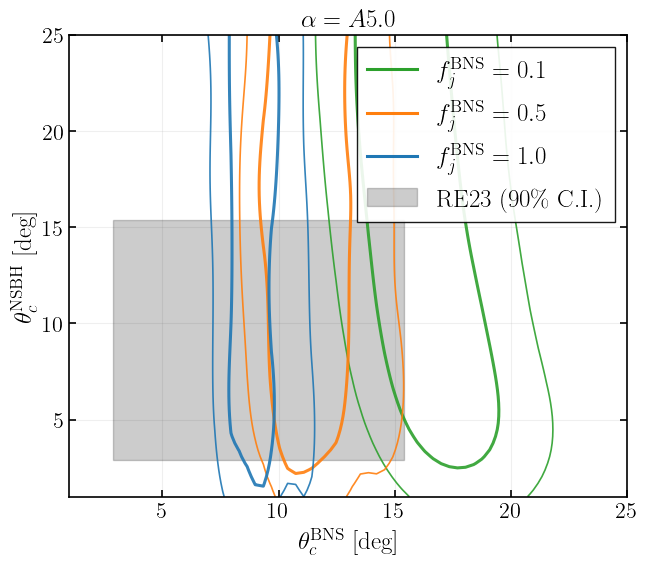

In [9]:
from mcmc_runner import plot_populations

# Evaluate and plot results for each simulated alpha
plot_populations(
    alphas=possible_alpha,
    fj_bns_values=FJ_BNS_VALUES,
    burn_frac=0.33,
    thin=10
)

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A0.5_fj0.1
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A0.5_fj0.5
Loading existing directory  : Output_files/lognormal_stage2_bns_plus_nsbh_alpha_A0.5_fj1.0
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat wi

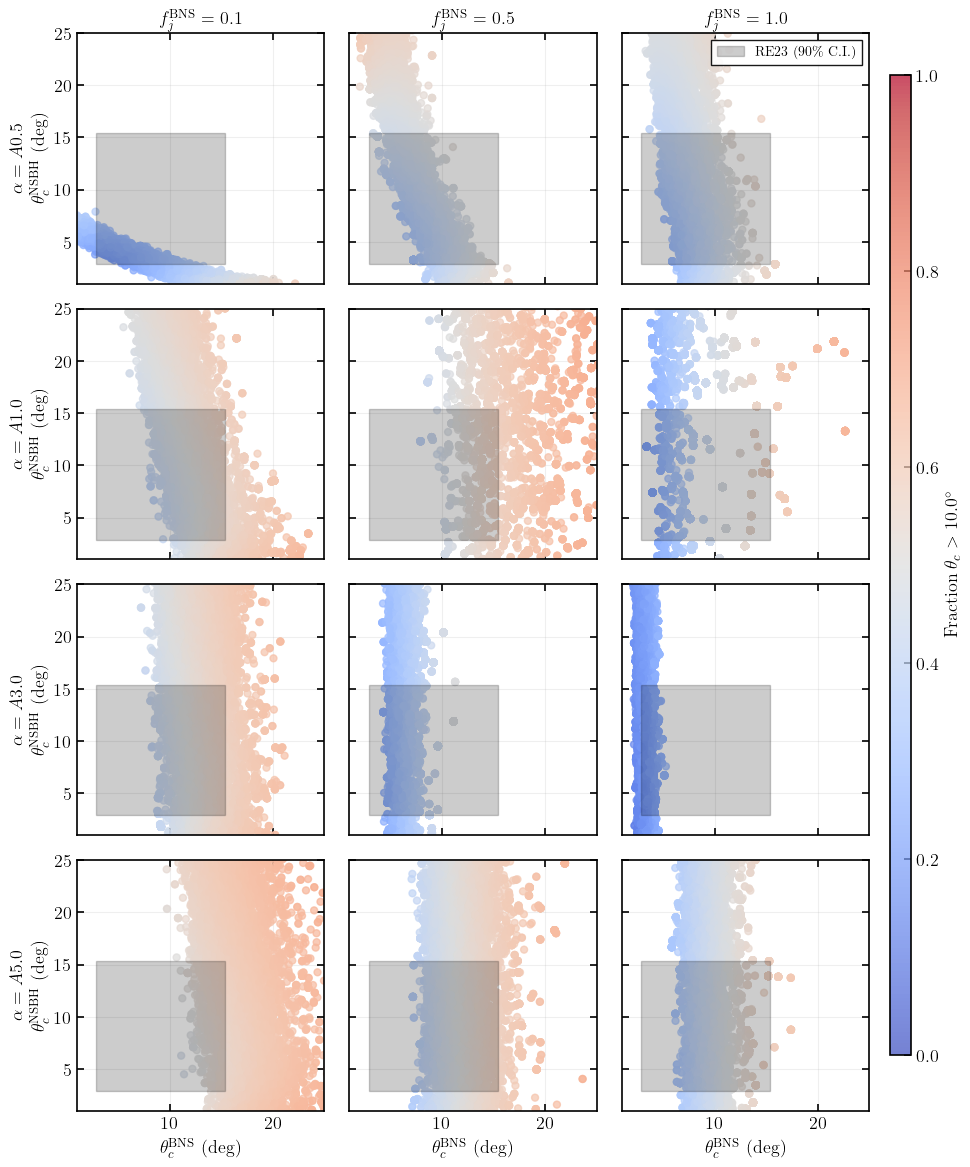

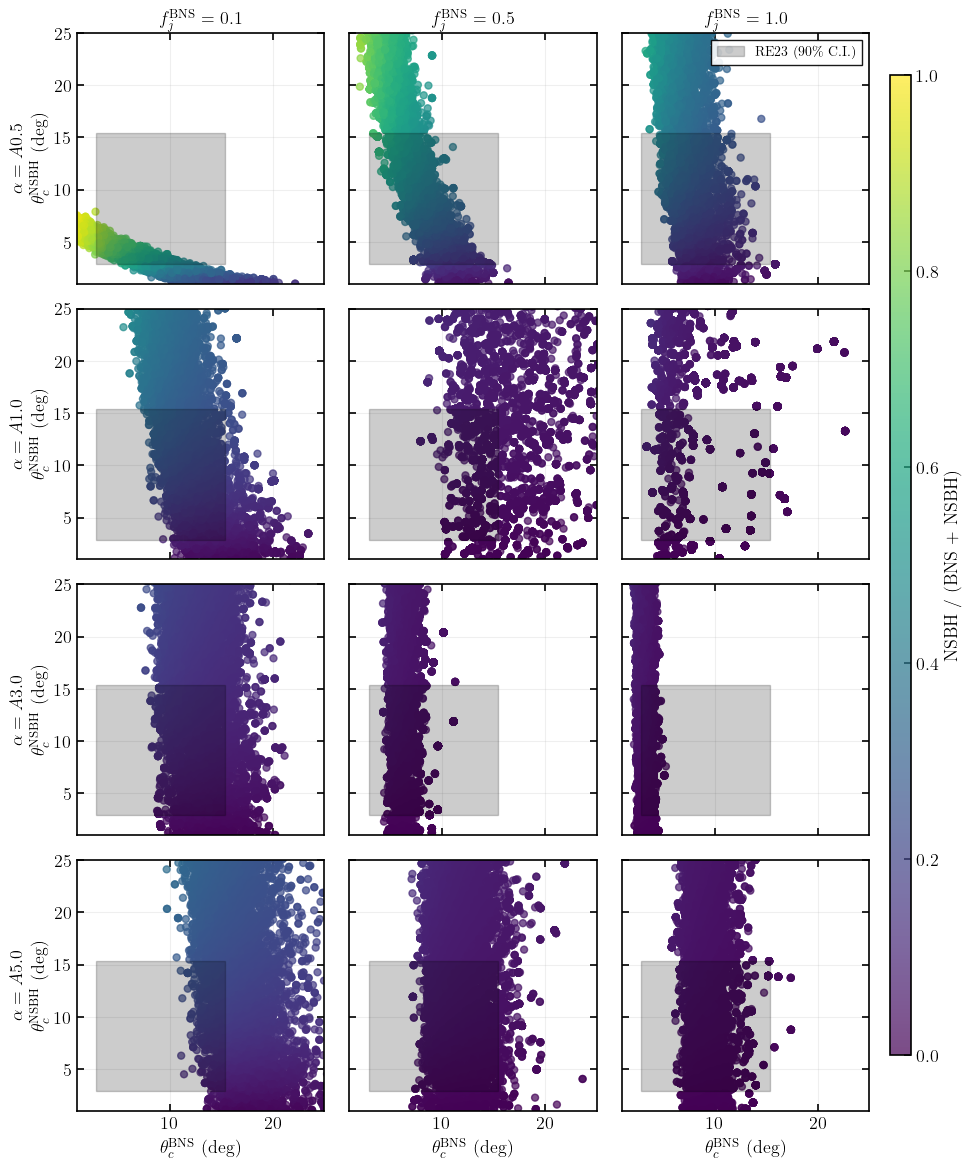

In [13]:
# =========================================================================
# Diagnostic Plots: Fraction > 10deg & NSBH Relative Contribution
# =========================================================================
from mcmc_runner import plotting_fractions

theta_threshold = 10.0
alpha_tests     = ["A0.5", "A1.0", "A3.0", "A5.0"]
fj_bns_tests    = [0.1, 0.5, 1.0]

# Pass lists to generate the shared-axis grids automatically:
plotting_fractions(
    alpha_val = alpha_tests, 
    fj_bns_val = fj_bns_tests, 
    theta_threshold = theta_threshold, 
    geom_eff = geom_eff_interp
)

# NOTE: You can selectively pass single values if you just want one diagnostic plot.
# Example: plotting_fractions("A1.0", 0.5, 10.0, geom_eff_interp)